## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [1]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.

! pip  install subword-nmt
! pip install nltk
! pip install torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.5 MB/s eta 0:00:00


In [2]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
path_do_data = '../../datasets/Machine_translation_EN_RU/data.txt'
if not os.path.exists(path_do_data):
    print("Dataset not found locally. Downloading from github.")
    !wget https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt -nc
    path_do_data = './data.txt'

Dataset not found locally. Downloading from github.
--2026-04-01 20:43:33--  https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12905334 (12M) [application/octet-stream]
Saving to: ‘data.txt’

data.txt            100%[===================>]  12.31M  --.-KB/s    in 0.05s   

2026-04-01 20:43:33 (231 MB/s) - ‘data.txt’ saved [12905334/12905334]



#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [3]:
# old deprecated code
import torch
import torch.nn as nn
import torch.optim as optim

# import torchtext
# from torchtext.datasets import TranslationDataset, Multi30k
# from torchtext.data import Field, BucketIterator
from datasets import load_dataset, Dataset as HFDataset
import pandas as pd
import numpy as np

import spacy

import random
import math
import time

import matplotlib
matplotlib.rcParams.update({'figure.figsize': (16, 12), 'font.size': 14})
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output

from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

In [4]:
tokenizer_W = WordPunctTokenizer()
def tokenize(x, tokenizer=tokenizer_W):
    return tokenizer.tokenize(x.lower())

In [5]:
from collections import Counter

class Vocab:
    def __init__(self, counter, min_freq, init_token, eos_token):
        self.itos = ['<pad>', init_token, eos_token, '<unk>']
        self.stoi = {token: i for i, token in enumerate(self.itos)}

        for token, freq in counter.items():
            if freq >= min_freq and token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def __len__(self):
        return len(self.itos)

class Field:
    def __init__(self, tokenize, init_token, eos_token, lower, name=None):
        self.tokenize = tokenize
        self.init_token = init_token
        self.eos_token = eos_token
        self.lower = lower
        self.name = name
        self.vocab = None

    def build_vocab(self, dataset, min_freq=1):
        counter = Counter()
        for example in dataset.examples:
            text = getattr(example, self.name)
            tokens = self.tokenize(text.lower() if self.lower else text)
            counter.update(tokens)

        self.vocab = Vocab(counter, min_freq, self.init_token, self.eos_token)

class TranslationDataset:
    def __init__(self, examples):
        self.examples = examples

    @classmethod
    def from_df(cls, df):
        class Example:
            def __init__(self, src, trg):
                self.src = src
                self.trg = trg

        examples = [Example(row['src'], row['trg']) for _, row in df.iterrows()]
        return cls(examples)

    def split(self, split_ratio):
        random.shuffle(self.examples)
        n = len(self.examples)
        train_end = int(n * split_ratio[0])
        valid_end = train_end + int(n * split_ratio[1])

        return (
            TranslationDataset(self.examples[:train_end]),
            TranslationDataset(self.examples[train_end:valid_end]),
            TranslationDataset(self.examples[valid_end:])
        )

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

SRC = Field(tokenize=tokenize,
            init_token = '<sos>',
            eos_token = '<eos>',
            lower = True,
            name='src')

TRG = Field(tokenize=tokenize,
            init_token = '<sos>',
            eos_token = '<eos>',
            lower = True,
            name='trg')

# dataset = torchtext.data.TabularDataset(
#     path=path_do_data,
#     format='tsv',
#     fields=[('trg', TRG), ('src', SRC)]
# )

raw_df = pd.read_csv(path_do_data, sep='\t', names=['trg', 'src'], header=None)
dataset = TranslationDataset.from_df(raw_df)

In [6]:
train_data, valid_data, test_data = dataset.split(split_ratio=[0.8, 0.05, 0.15])

In [7]:
print(f"Number of training examples: {len(train_data.examples)}")
print(f"Number of validation examples: {len(valid_data.examples)}")
print(f"Number of testing examples: {len(test_data.examples)}")

Number of training examples: 40000
Number of validation examples: 2500
Number of testing examples: 7500


In [8]:
SRC.build_vocab(train_data, min_freq = 3)
TRG.build_vocab(train_data, min_freq = 3)

In [9]:
print(f"Unique tokens in source (ru) vocabulary: {len(SRC.vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")

Unique tokens in source (ru) vocabulary: 9242
Unique tokens in target (en) vocabulary: 6662


Here are tokens from original (RU) corpus:

In [10]:
SRC.vocab.itos[::1000]

['<pad>',
 'батуми',
 'предназначены',
 'радостью',
 'cloud',
 'taksim',
 'like',
 'полем',
 'высокими',
 'снек']

And from target (EN) corpus:

In [11]:
TRG.vocab.itos[::1000]

['<pad>', 'min', 'pleasant', 'premium', 'agde', 'vorokhta', 'río']

And here is example from train dataset:

In [12]:
print(vars(train_data.examples[9]))

{'src': 'Из окон апартаментов открывается вид на сад и горы.', 'trg': 'There are garden and mountain views from the accommodation.'}


Let's check the length distributions:

Length distribution in Train data


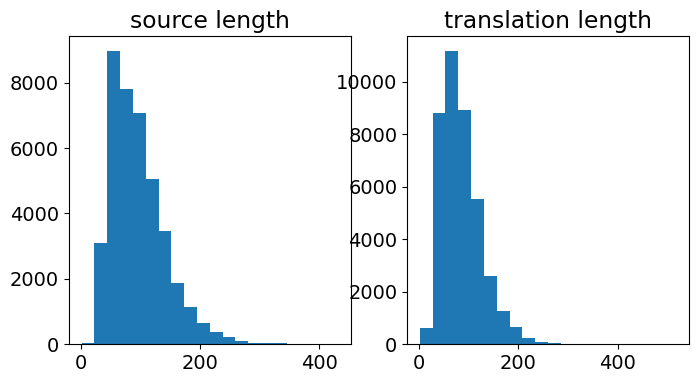

In [13]:
src_length = map(len, [vars(x)['src'] for x in train_data.examples])
trg_length = map(len, [vars(x)['trg'] for x in train_data.examples])

print('Length distribution in Train data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

Length distribution in Test data


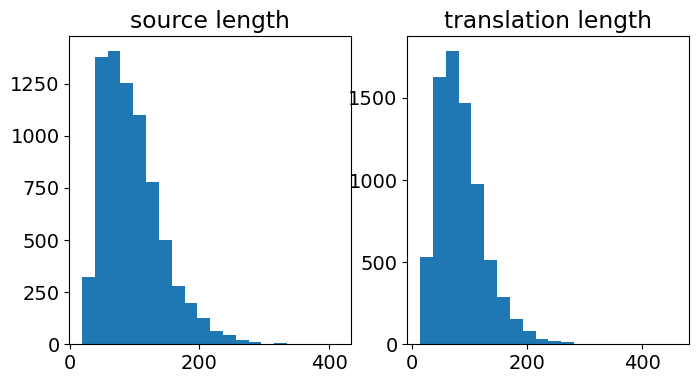

In [14]:
src_length = map(len, [vars(x)['src'] for x in test_data.examples])
trg_length = map(len, [vars(x)['trg'] for x in test_data.examples])

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
device

device(type='cuda')

In [32]:
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

class Batch:
    def __init__(self, src, trg, device):
        self.src = src.to(device)
        self.trg = trg.to(device)

def collate_fn(batch, src_field, trg_field, device):
    src_list, trg_list = [], []

    for ex in batch:
        src_tokens = src_field.tokenize(ex.src.lower() if src_field.lower else ex.src)
        src_indices = [src_field.vocab.stoi.get(t, src_field.vocab.stoi['<unk>']) for t in src_tokens]
        src_indices = [1] + src_indices + [2]
        src_list.append(torch.tensor(src_indices))

        trg_tokens = trg_field.tokenize(ex.trg.lower() if trg_field.lower else ex.trg)
        trg_indices = [trg_field.vocab.stoi.get(t, trg_field.vocab.stoi['<unk>']) for t in trg_tokens]
        trg_indices = [1] + trg_indices + [2]
        trg_list.append(torch.tensor(trg_indices))

    src_padded = pad_sequence(src_list, padding_value=0).to(device)
    trg_padded = pad_sequence(trg_list, padding_value=0).to(device)

    return Batch(src_padded, trg_padded, device)

class BucketIterator:
    @staticmethod
    def splits(datasets, batch_size, device, sort_key):
        train_data, valid_data, test_data = datasets
        valid_data.examples.sort(key=sort_key)
        test_data.examples.sort(key=sort_key)

        train_loader = DataLoader(train_data.examples, batch_size=batch_size,
                                  collate_fn=lambda b: collate_fn(b, SRC, TRG, device))
        valid_loader = DataLoader(valid_data.examples, batch_size=batch_size,
                                  collate_fn=lambda b: collate_fn(b, SRC, TRG, device))
        test_loader = DataLoader(test_data.examples, batch_size=batch_size,
                                 collate_fn=lambda b: collate_fn(b, SRC, TRG, device))

        return train_loader, valid_loader, test_loader


def _len_sort_key(x):
    return len(x.src)

BATCH_SIZE = 64

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    device = device,
    sort_key=_len_sort_key
)

In [33]:
for x in train_iterator:
    break
print(x)
print(x.src.shape, x.trg.shape)

torch.Size([48, 64]) torch.Size([36, 64])


In [34]:
%%writefile my_network.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        h = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)
        outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.attn(torch.cat((h, outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return F.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(hid_dim + emb_dim, hid_dim, n_layers, dropout=dropout)
        self.fc_out = nn.Linear(hid_dim * 2 + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        outputs = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(a, outputs).permute(1, 0, 2)
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc_out(torch.cat((output.squeeze(0), weighted.squeeze(0), embedded.squeeze(0)), dim=1))
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        trg_len, batch_size = trg.shape
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = trg[0,:]
        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden, encoder_outputs)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[t] if teacher_force else top1
        return outputs

Overwriting my_network.py


In [35]:
import my_network
Encoder = my_network.Encoder
Decoder = my_network.Decoder
Seq2Seq = my_network.Seq2Seq

In [36]:
Attention = my_network.Attention

INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HID_DIM = 256
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)

attn = Attention(HID_DIM)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT, attn)

# dont forget to put the model to the right device
model = Seq2Seq(enc, dec, device).to(device)

In [37]:
def init_weights(m):
    # <YOUR CODE HERE>
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9242, 128)
    (rnn): GRU(128, 256, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn): Linear(in_features=512, out_features=256, bias=True)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(6662, 128)
    (rnn): GRU(384, 256, num_layers=2, dropout=0.5)
    (fc_out): Linear(in_features=640, out_features=6662, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [38]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 8,016,646 trainable parameters


In [39]:
PAD_IDX = TRG.vocab.stoi['<pad>']
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index = PAD_IDX)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [41]:
def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()

    epoch_loss = 0
    history = []
    for i, batch in enumerate(iterator):

        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()

        output = model(src, trg)

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output[1:].view(-1, output.shape[-1])
        trg = trg[1:].view(-1)

        #trg = [(trg sent len - 1) * batch size]
        #output = [(trg sent len - 1) * batch size, output dim]

        loss = criterion(output, trg)

        loss.backward()

        # Let's clip the gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

        history.append(loss.cpu().data.numpy())
        if (i+1)%10==0:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

            clear_output(True)
            ax[0].plot(history, label='train loss')
            ax[0].set_xlabel('Batch')
            ax[0].set_title('Train loss')
            if train_history is not None:
                ax[1].plot(train_history, label='general train history')
                ax[1].set_xlabel('Epoch')
            if valid_history is not None:
                ax[1].plot(valid_history, label='general valid history')
            plt.legend()

            plt.show()
            plt.close(fig)



    return epoch_loss / len(iterator)

In [42]:
def evaluate(model, iterator, criterion):

    model.eval()

    epoch_loss = 0

    history = []

    with torch.no_grad():

        for i, batch in enumerate(iterator):

            src = batch.src
            trg = batch.trg

            output = model(src, trg, 0) #turn off teacher forcing

            #trg = [trg sent len, batch size]
            #output = [trg sent len, batch size, output dim]

            output = output[1:].view(-1, output.shape[-1])
            trg = trg[1:].view(-1)

            #trg = [(trg sent len - 1) * batch size]
            #output = [(trg sent len - 1) * batch size, output dim]

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [43]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [44]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

In [46]:
def quick_prepare(dataset):
    prepared = []
    for ex in dataset.examples:
        src_ids = [SRC.vocab.stoi['<sos>']] + \
                  [SRC.vocab.stoi.get(t, SRC.vocab.stoi['<unk>']) for t in tokenize(ex.src)] + \
                  [SRC.vocab.stoi['<eos>']]
        trg_ids = [TRG.vocab.stoi['<sos>']] + \
                  [TRG.vocab.stoi.get(t, TRG.vocab.stoi['<unk>']) for t in tokenize(ex.trg)] + \
                  [TRG.vocab.stoi['<eos>']]
        prepared.append({'src': torch.tensor(src_ids), 'trg': torch.tensor(trg_ids)})
    prepared.sort(key=lambda x: len(x['src']))
    return prepared

train_fast = quick_prepare(train_data)
valid_fast = quick_prepare(valid_data)
test_fast  = quick_prepare(test_data)

def fast_collate_fn(batch):
    src = pad_sequence([item['src'] for item in batch], padding_value=0)
    trg = pad_sequence([item['trg'] for item in batch], padding_value=0)
    return Batch(src, trg, device)

from torch.utils.data import DataLoader
train_iterator = DataLoader(train_fast, batch_size=64, shuffle=True, collate_fn=fast_collate_fn)
valid_iterator = DataLoader(valid_fast, batch_size=64, collate_fn=fast_collate_fn)
test_iterator  = DataLoader(test_fast, batch_size=64, collate_fn=fast_collate_fn)

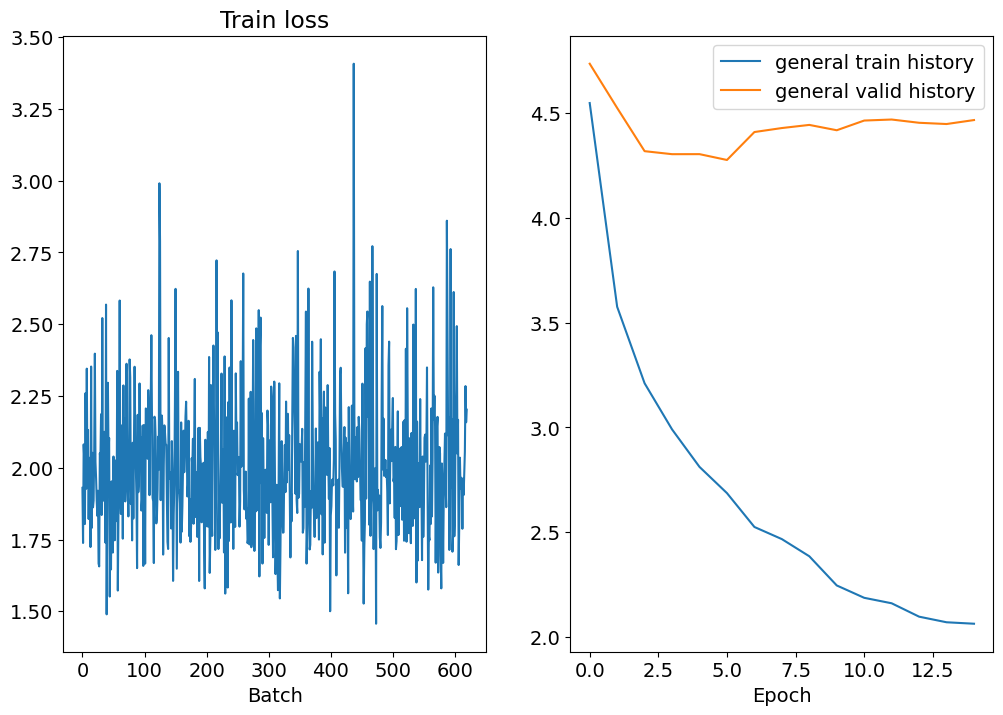

Epoch: 10 | Time: 2m 35s
	Train Loss: 2.007 | Train PPL:   7.441
	 Val. Loss: 4.478 |  Val. PPL:  88.093


In [47]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_iterator, criterion)
    scheduler.step(valid_loss)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

__Let's take a look at our network quality__:

In [52]:
del utils

NameError: name 'utils' is not defined

In [55]:
import utils
import importlib
importlib.reload(utils)

generate_translation = utils.generate_translation
remove_tech_tokens = utils.remove_tech_tokens
get_text = utils.get_text
flatten = utils.flatten

In [56]:
batch = next(iter(test_iterator))

In [57]:
for idx in [1,2]:
    src = batch.src[:, idx:idx+1]
    trg = batch.trg[:, idx:idx+1]
    generate_translation(src, trg, model, TRG.vocab)

Original: towels are featured .
Generated: towels are available .

Original: towels are featured .
Generated: towels are available .



In [58]:
from nltk.translate.bleu_score import corpus_bleu

#     """ Estimates corpora-level BLEU score of model's translations given inp and reference out """
#     translations, _ = model.translate_lines(inp_lines, **flags)
#     # Note: if you experience out-of-memory error, split input lines into batches and translate separately
#     return corpus_bleu([[ref] for ref in out_lines], translations) * 100

In [59]:
import tqdm

In [60]:
original_text = []
generated_text = []
model.eval()
with torch.no_grad():

    for i, batch in tqdm.tqdm(enumerate(test_iterator)):

        src = batch.src
        trg = batch.trg

        output = model(src, trg, 0) #turn off teacher forcing

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

# original_text = flatten(original_text)
# generated_text = flatten(generated_text)

118it [00:06, 18.71it/s]


In [61]:
corpus_bleu([[text] for text in original_text], generated_text) * 100

27.254815425886125